### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

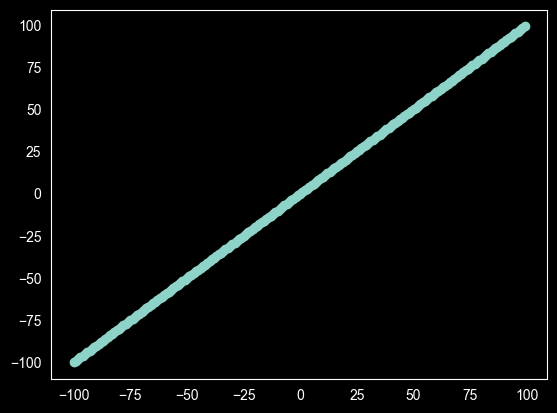

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

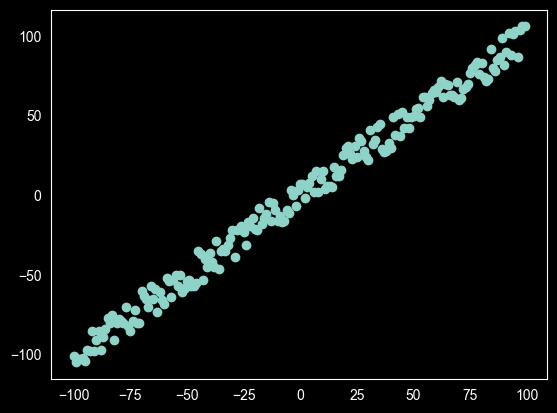

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

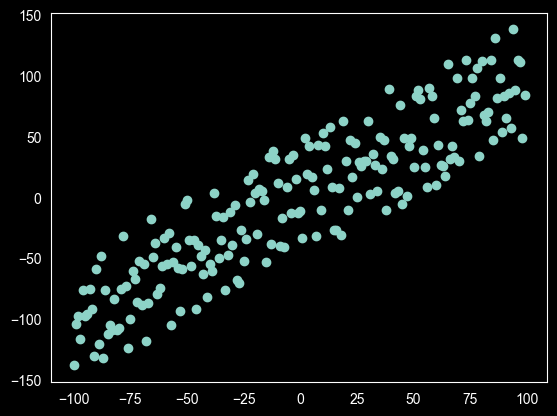

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

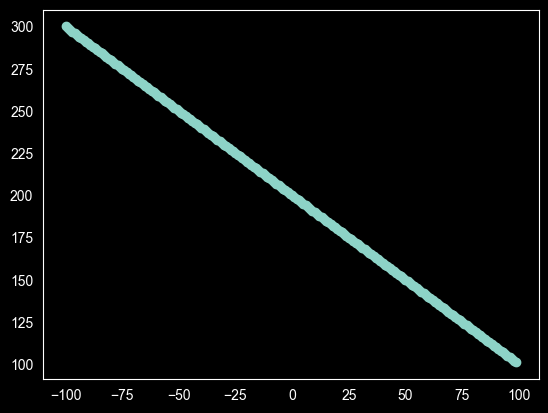

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

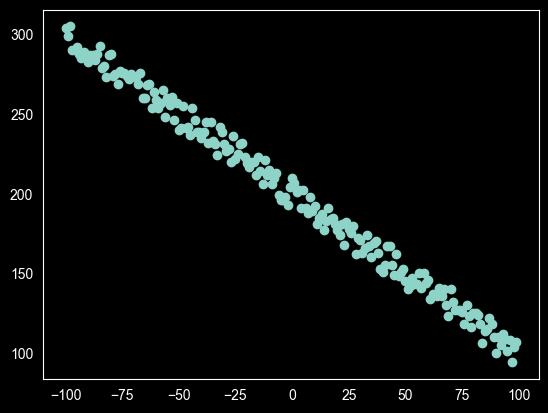

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

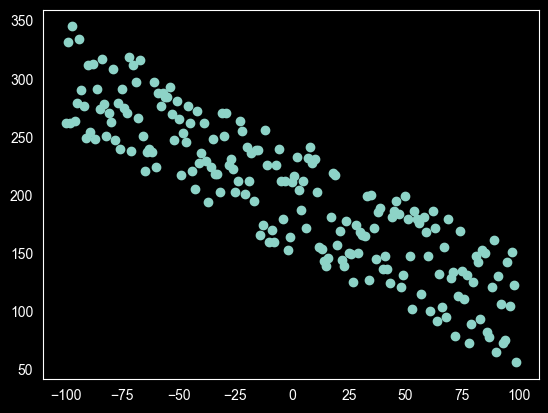

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

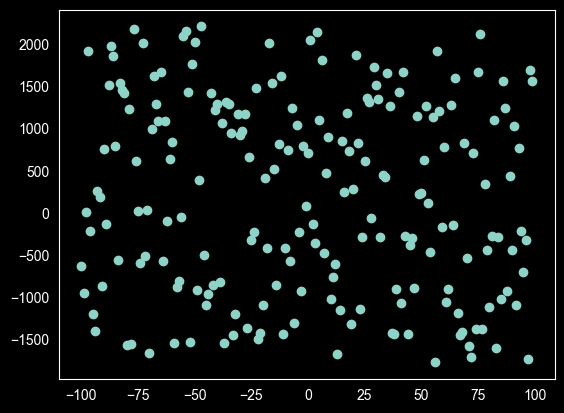

In [8]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Utils

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    return round(mse, 4)

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)


In [12]:
def plot(x, y, m, c):
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

### Solve by Normal Equation

In [13]:
def solve_by_norm_eq(x, y):
    x_b = np.array([[1, i] for i in x])
    c, m = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

Slope : 1.0   y-Intercept : -0.0   MSE : 0.0   R2 : 1.0


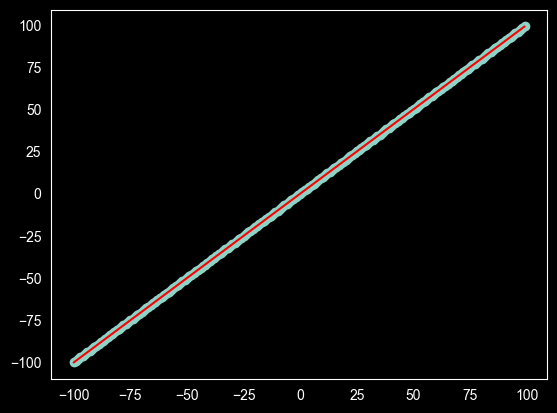

In [14]:
# Solve for Data 1
solve_by_norm_eq(x1, y1)

Slope : 1.0121   y-Intercept : -0.0689   MSE : 38.1378   R2 : 0.989


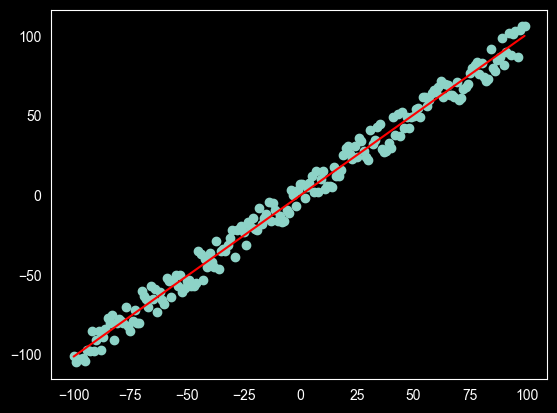

In [15]:
# Solve for Data 2
solve_by_norm_eq(x2, y2)

Slope : 0.9844   y-Intercept : -1.9378   MSE : 777.0658   R2 : 0.8061


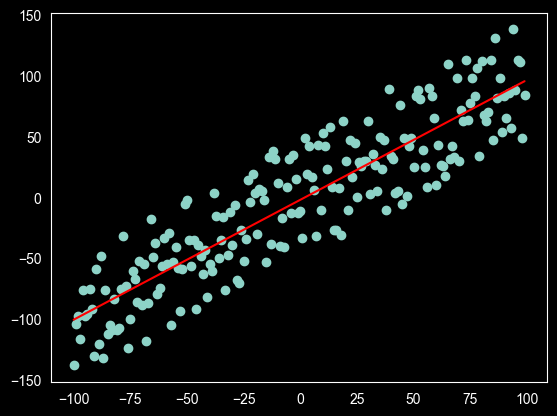

In [16]:
# Solve for Data 3
solve_by_norm_eq(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


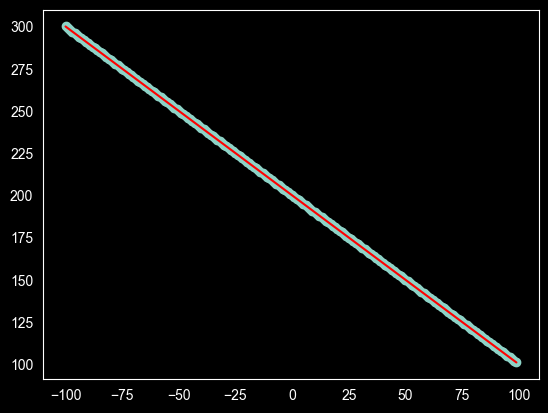

In [17]:
# Solve for Data 4
solve_by_norm_eq(x4, y4)

Slope : -0.9929   y-Intercept : 200.0486   MSE : 30.2744   R2 : 0.9909


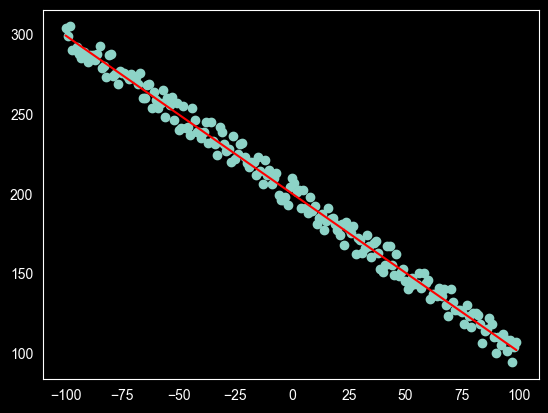

In [18]:
# Solve for Data 5
solve_by_norm_eq(x5, y5)

Slope : -0.9906   y-Intercept : 200.2247   MSE : 867.2701   R2 : 0.7904


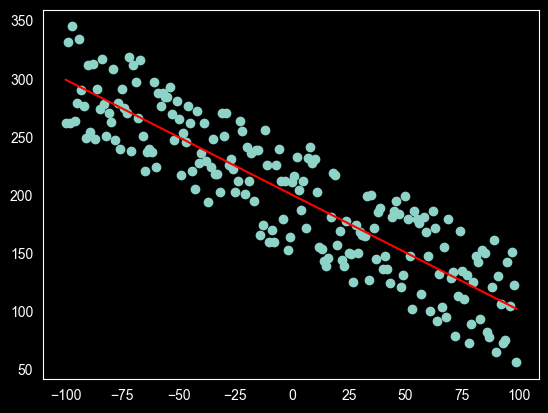

In [19]:
# Solve for Data 6
solve_by_norm_eq(x6, y6)

Slope : -2.138   y-Intercept : 210.076   MSE : 1299261.7976   R2 : 0.0116


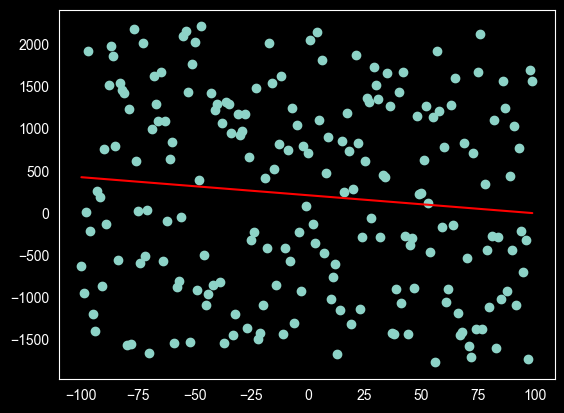

In [20]:
# Solve for Data 7
solve_by_norm_eq(x7, y7)

### Solve by SVD

In [21]:
def solve_by_svd(x, y):
    X = np.array([[1, i] for i in x])
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    S_inv = np.diag(1 / S)
    theta = Vt.T @ S_inv @ U.T @ y
    c, m = theta[0], theta[1]
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

Slope : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


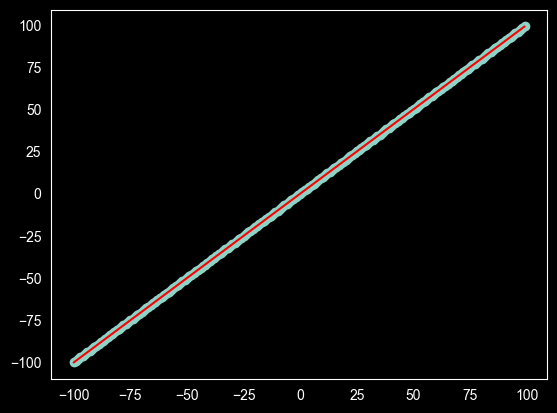

In [22]:
# Solve for Data 1
solve_by_svd(x1, y1)

Slope : 1.0121   y-Intercept : -0.0689   MSE : 38.1378   R2 : 0.989


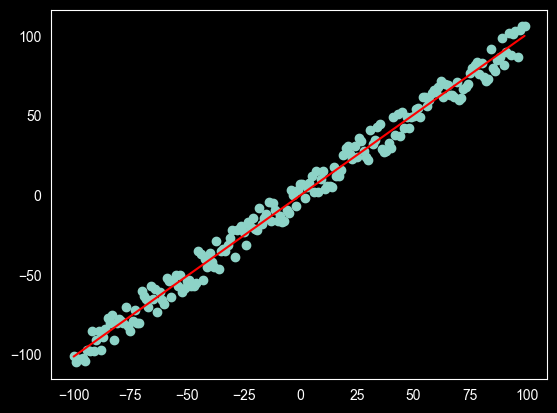

In [23]:
# Solve for Data 2
solve_by_svd(x2, y2)

Slope : 0.9844   y-Intercept : -1.9378   MSE : 777.0658   R2 : 0.8061


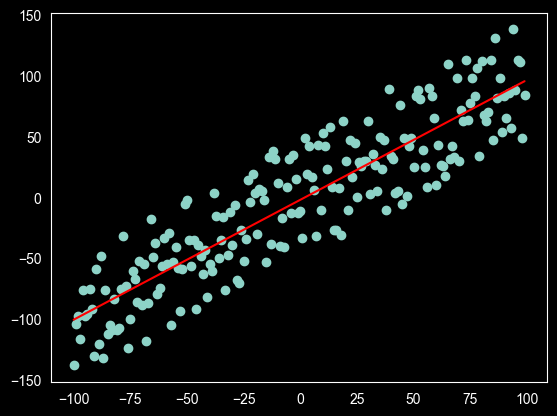

In [24]:
# Solve for Data 3
solve_by_svd(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


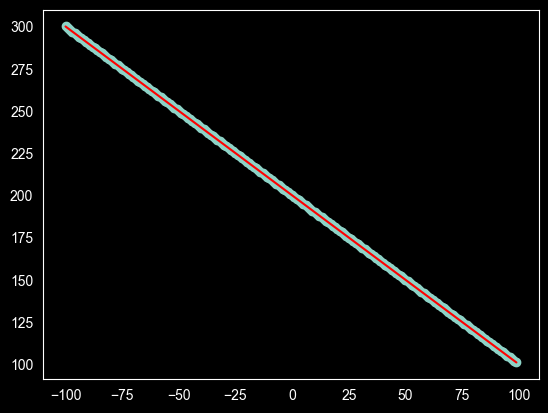

In [25]:
# Solve for Data 4
solve_by_svd(x4, y4)

Slope : -0.9929   y-Intercept : 200.0486   MSE : 30.2744   R2 : 0.9909


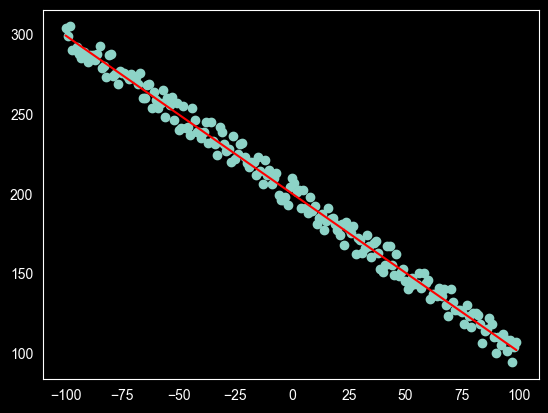

In [26]:
# Solve for Data 5
solve_by_svd(x5, y5)

Slope : -0.9906   y-Intercept : 200.2247   MSE : 867.2701   R2 : 0.7904


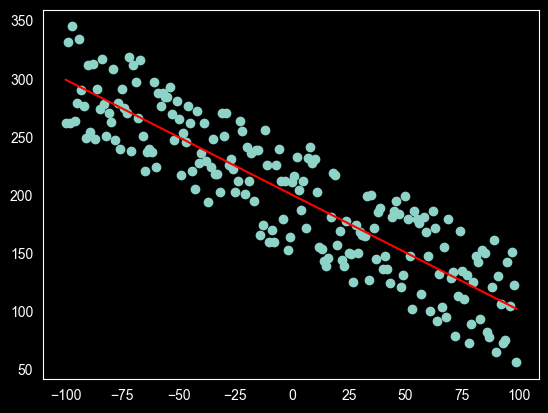

In [27]:
# Solve for Data 6
solve_by_svd(x6, y6)

Slope : -2.138   y-Intercept : 210.076   MSE : 1299261.7976   R2 : 0.0116


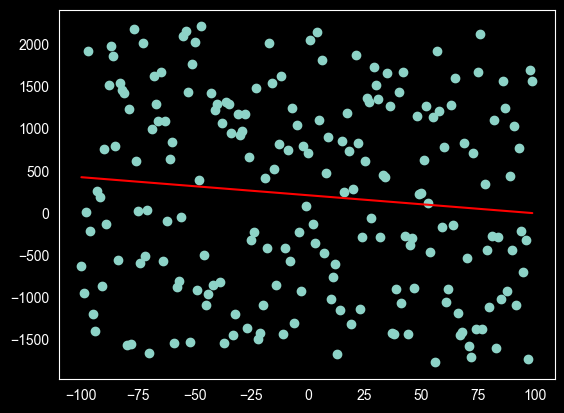

In [28]:
# Solve for Data 7
solve_by_svd(x7, y7)

### Solve by Grid Search

In [64]:
def solve_by_grid_search(x, y):
    best_b0 = None
    best_b1 = None
    best_mse = float("inf")
    for b0 in range(-20, 2100):
        for b1 in range(-10, 11):
            b00 = b0/10
            b11 = b1/10
            predictions = []
            for xi in x:
                y_hat = b00 + b11 * xi
                predictions.append(y_hat)
            squared_errors = []
            for yi, y_hat in zip(y, predictions):
                squared_errors.append((yi - y_hat) ** 2)
            mse_ = sum(squared_errors) / len(y)
            if mse_ < best_mse:
                best_mse = mse_
                best_b0 = b00
                best_b1 = b11
    c = best_b0
    m = best_b1
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", c, "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

Slope : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


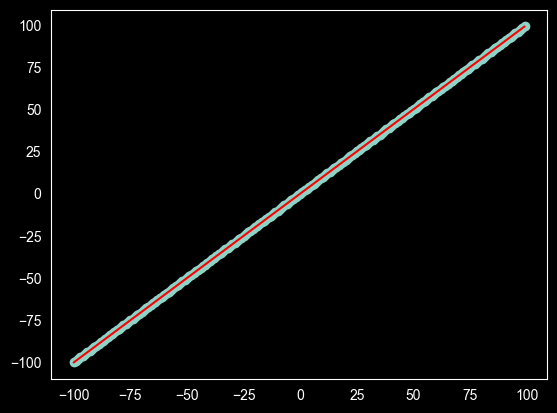

In [65]:
# Solve for Data 1
solve_by_grid_search(x1, y1)

Slope : 1.0   y-Intercept : -0.1   MSE : 38.63   R2 : 0.9888


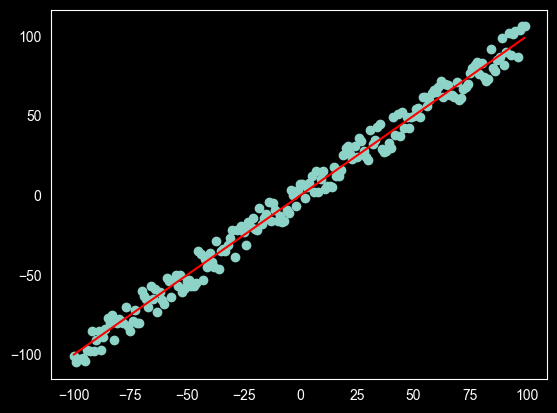

In [66]:
# Solve for Data 2
solve_by_grid_search(x2, y2)

Slope : 1.0   y-Intercept : -1.9   MSE : 777.876   R2 : 0.8059


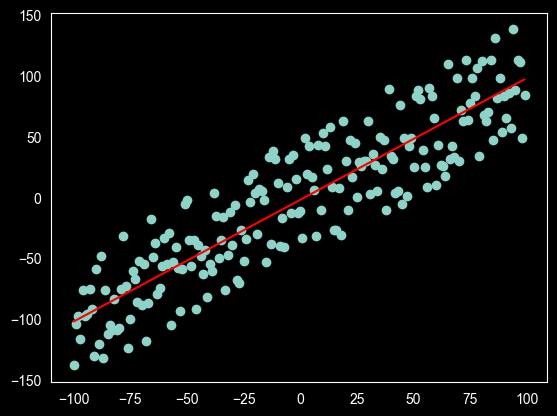

In [67]:
# Solve for Data 3
solve_by_grid_search(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


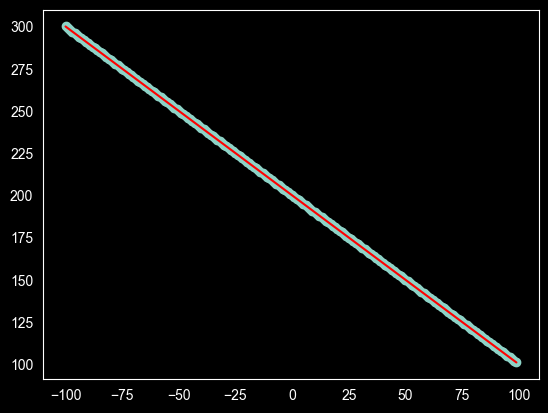

In [68]:
# Solve for Data 4
solve_by_grid_search(x4, y4)

Slope : -1.0   y-Intercept : 200.0   MSE : 30.445   R2 : 0.9908


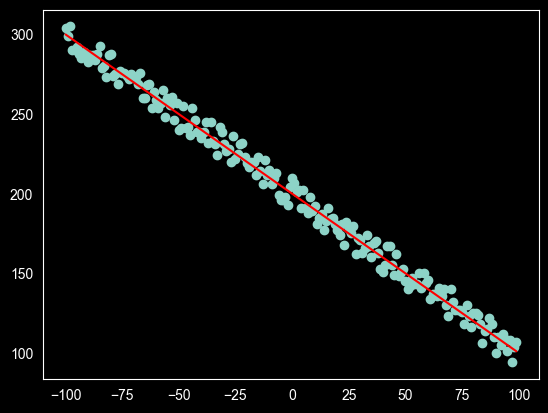

In [69]:
# Solve for Data 5
solve_by_grid_search(x5, y5)

Slope : -1.0   y-Intercept : 200.2   MSE : 867.562   R2 : 0.7904


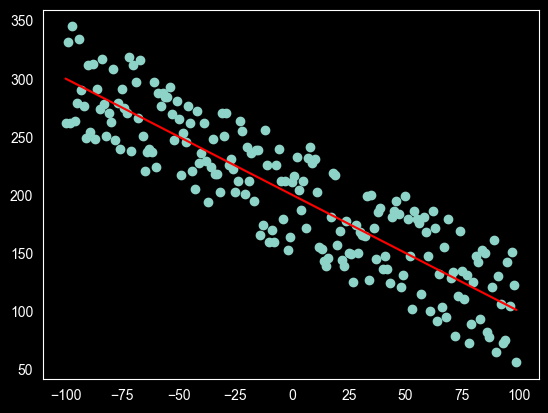

In [70]:
# Solve for Data 6
solve_by_grid_search(x6, y6)

Slope : -1.0   y-Intercept : 209.9   MSE : 1303578.794   R2 : 0.0083


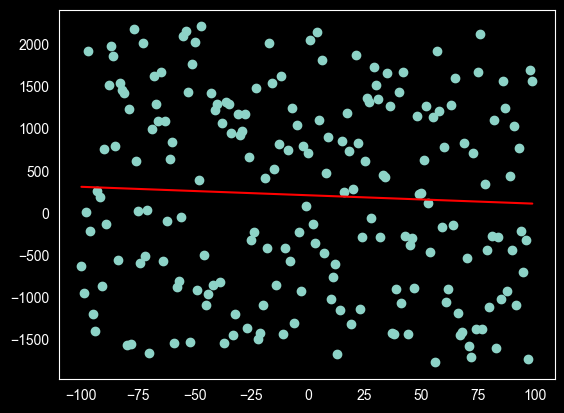

In [71]:
# Solve for Data 7
solve_by_grid_search(x7, y7)

### Solve by Gradient Descent

In [37]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1):
    x_scaled = (x-x.mean())/x.std()
    y_scaled = (y-y.mean())/y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    m = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / m * x_b.T @ (x_b @ theta - y_scaled)
        theta = theta - eta * gradients
    c, m = round(theta[0][0], 4), round(theta[-1][0], 4)
    m = m * y.std() / x.std()
    c = c * y.std() + y.mean() - m * x.mean()
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", c, "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

Slope : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


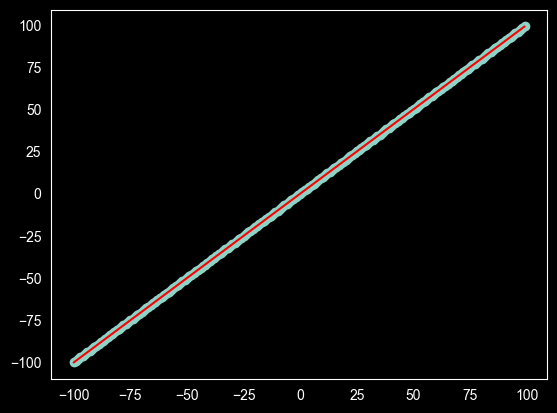

In [38]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

Slope : 1.0121822495761879   y-Intercept : -0.06890887521190603   MSE : 38.1378   R2 : 0.989


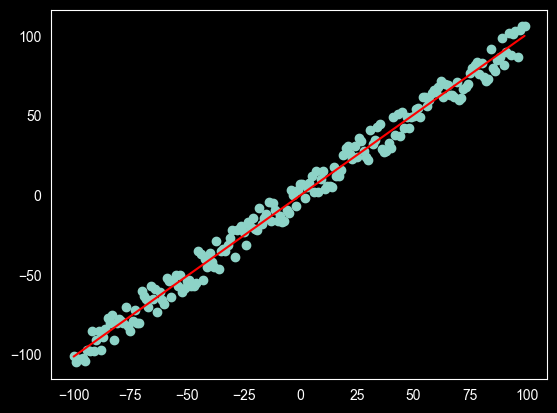

In [39]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

Slope : 0.9843932122840927   y-Intercept : -1.9378033938579537   MSE : 777.0658   R2 : 0.8061


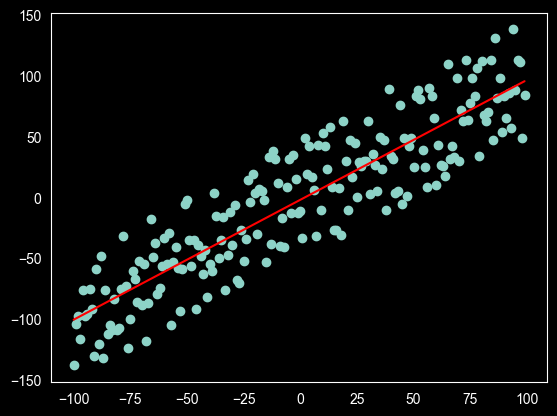

In [40]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


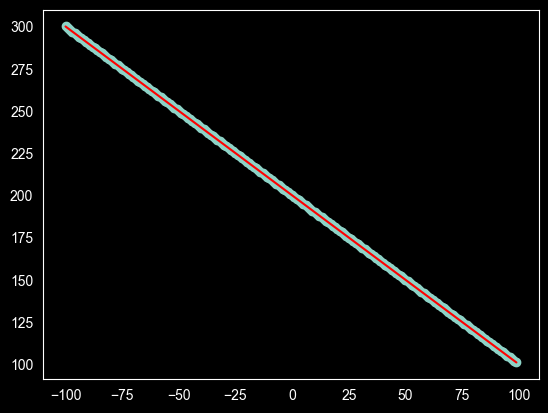

In [41]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

Slope : -0.992862609541532   y-Intercept : 200.04856869522922   MSE : 30.2744   R2 : 0.9909


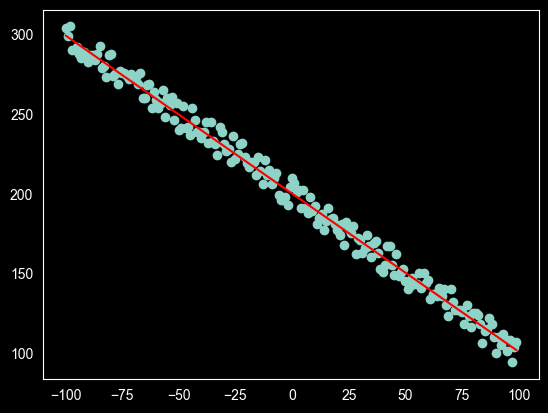

In [42]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

Slope : -0.9906874376137085   y-Intercept : 200.22465628119315   MSE : 867.2701   R2 : 0.7904


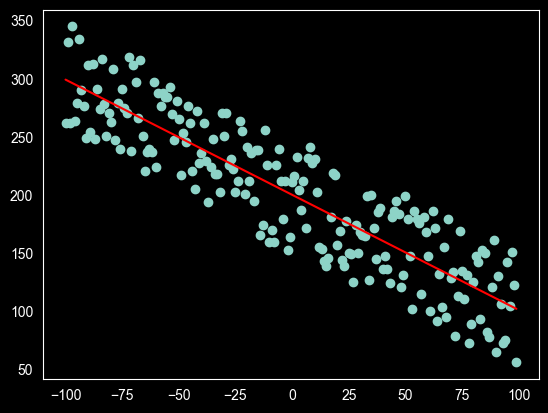

In [43]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

Slope : -2.13875816383661   y-Intercept : 210.0756209180817   MSE : 1299261.7997   R2 : 0.0116


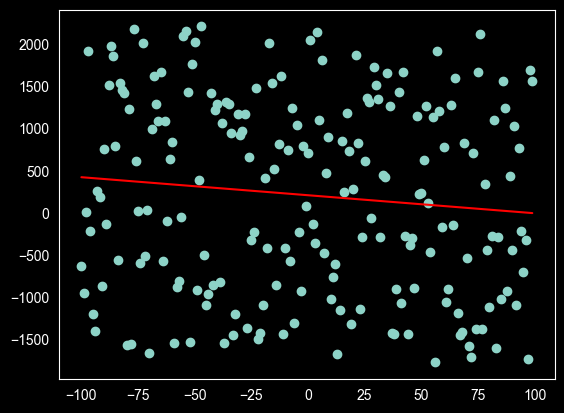

In [44]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [45]:
from sklearn.linear_model import LinearRegression

def get_model(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m[0], "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)


Slope : 1.0   y-Intercept : 0.0   MSE : 0.0   R2 : 1.0


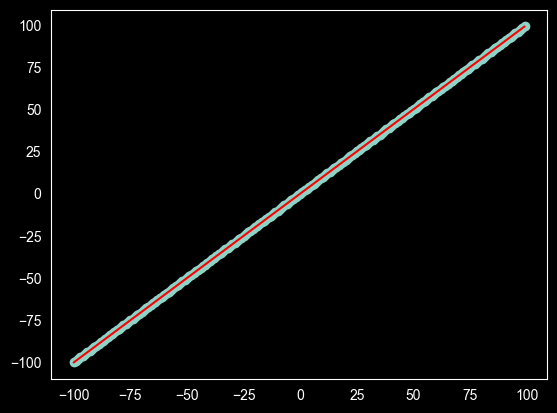

In [47]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

Slope : 1.01214355358884   y-Intercept : -0.0689   MSE : 38.13783430960774   R2 : 0.9889546296846029


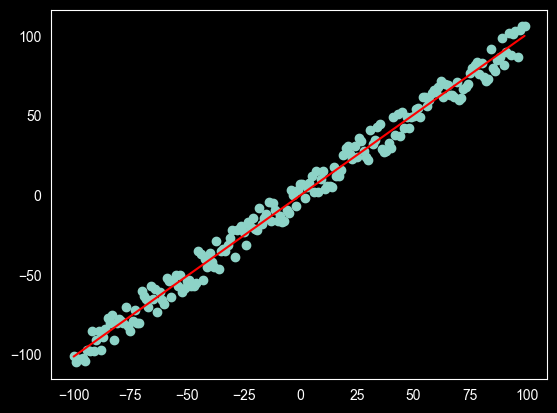

In [48]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

Slope : 0.9844176104402613   y-Intercept : -1.9378   MSE : 777.0657506862669   R2 : 0.8060847960893964


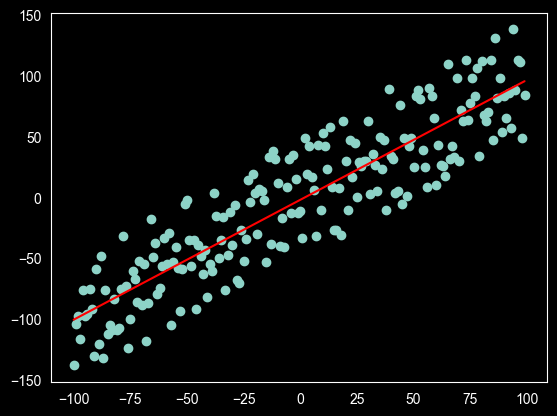

In [49]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

Slope : -1.0   y-Intercept : 200.0   MSE : 0.0   R2 : 1.0


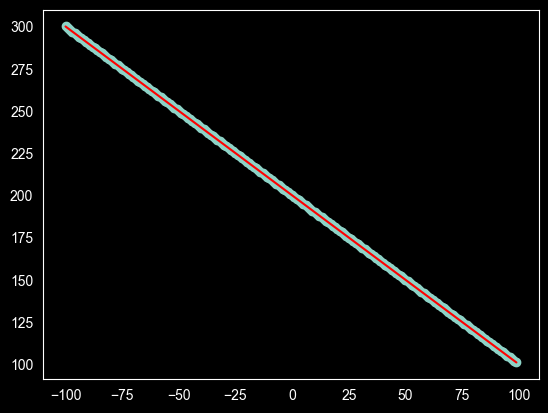

In [50]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

Slope : -0.9928875721893048   y-Intercept : 200.0486   MSE : 30.274357117677948   R2 : 0.9908709832692243


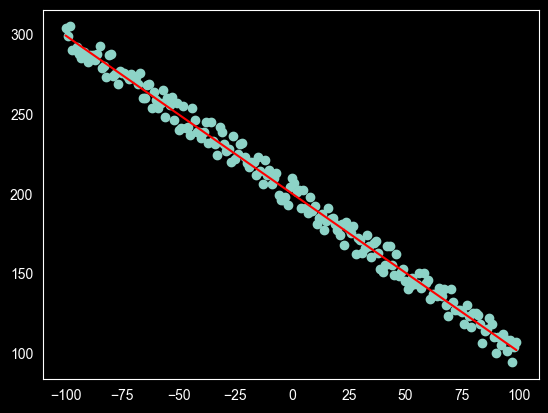

In [51]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

Slope : -0.9906487662191557   y-Intercept : 200.2247   MSE : 867.2701220430513   R2 : 0.7904370971053538


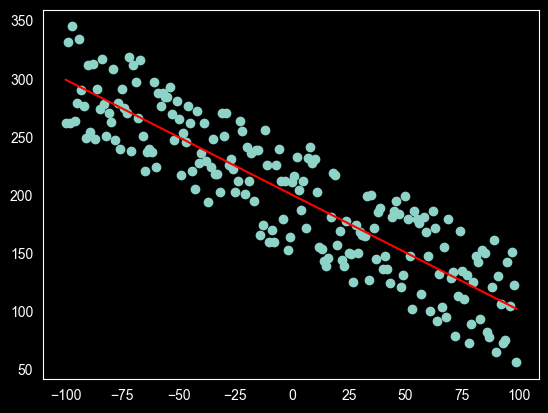

In [52]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

Slope : -2.137965199129978   y-Intercept : 210.076   MSE : 1299261.797573963   R2 : 0.011590690502724654


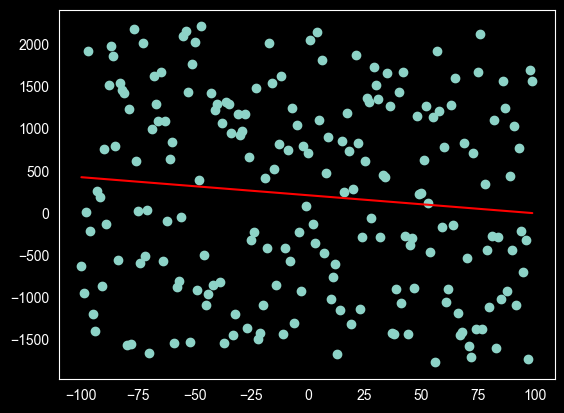

In [53]:
# Solve for Data 7
solve_by_sklearn(x7, y7)